In [ ]:
import tensorflow as tf

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"✅ GPU Detected: {len(gpus)} Physical GPU(s), {len(logical_gpus)} Logical GPU(s)")
        print(f"GPU Details: {tf.test.gpu_device_name()}")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("❌ No GPU detected. Please go to Runtime > Change runtime type and select T4 GPU.")

✅ GPU Detected: 1 Physical GPU(s), 1 Logical GPU(s)
GPU Details: /device:GPU:0


In [ ]:
import tensorflow as tf

# Check if TensorFlow is built with CUDA
print(f"TensorFlow Built with CUDA: {tf.test.is_built_with_cuda()}")

# Check for available GPU devices
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ CUDA Enabled GPU Detected: {len(gpus)}")
    for gpu in gpus:
        print(f"   - Device: {gpu.name}")
        # Optional: Print GPU details
        !nvidia-smi
else:
    print("❌ No GPU detected. Please ensure 'T4 GPU' is selected in Runtime settings.")

TensorFlow Built with CUDA: True
✅ CUDA Enabled GPU Detected: 1
   - Device: /physical_device:GPU:0
Mon Dec  8 08:59:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P0             26W /   70W |     102MiB /  15360MiB |      0%      Default |
|                                       

In [ ]:
!pip install opendatasets


In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/jehanbhathena/weather-dataset/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sathyan 
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jehanbhathena/weather-dataset


100%|██████████| 587M/587M [00:11<00:00, 52.0MB/s]


Change the Model Architecture

VGG-19 is an older model (2014) that is very powerful but also very "simple" in its structure. More modern models like Inception V3 and ResNet50 are specifically designed to solve this exact problem.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMAGE_SIZE = (224, 224) # ResNet50 also uses 224x224
BATCH_SIZE = 32
DATA_DIR = '/content/weather-dataset/dataset'

# --- KEY CHANGE HERE ---
# We now use 'preprocess_input' specific to ResNet
# We have REMOVED rescale=1./255
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # <-- This is the new part
    validation_split=0.20,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Also apply it to the validation generator
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # <-- This is the new part
    validation_split=0.20
)

# --- The rest is the same ---
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = validation_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 5493 images belonging to 11 classes.
Found 1369 images belonging to 11 classes.


Build the ResNet50 Model

Now, in a new cell, build the ResNet50 model. We'll use GlobalAveragePooling2D instead of Flatten, as it's a more modern technique that works very well with ResNet

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

# 1. Load the ResNet50 base model
base_model_resnet = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the base model
base_model_resnet.trainable = False

# 3. Add our new custom classifier
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x) # This layer is better than Flatten for ResNet
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(11, activation='softmax')(x)

# 4. Create the final model
model_resnet = Model(inputs=base_model_resnet.input, outputs=predictions)

# 5. Compile the model
model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Print the model summary
model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,403 (90.99 MB)

 Trainable params: 263,691 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train the new ResNet50 model
history_resnet = model_resnet.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 111s 562ms/step - accuracy: 0.5765 - loss: 1.3665 - val_accuracy: 0.8590 - val_loss: 0.4418
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 88s 512ms/step - accuracy: 0.8337 - loss: 0.5025 - val_accuracy: 0.8773 - val_loss: 0.3988
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 83s 478ms/step - accuracy: 0.8568 - loss: 0.4584 - val_accuracy: 0.8744 - val_loss: 0.3851
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 83s 481ms/step - accuracy: 0.8637 - loss: 0.3957 - val_accuracy: 0.8707 - val_loss: 0.3805
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 82s 477ms/step - accuracy: 0.8839 - loss: 0.3431 - val_accuracy: 0.8700 - val_loss: 0.3873
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 82s 477ms/step - accuracy: 0.8932 - loss: 0.3226 - val_accuracy: 0.8787 - val_loss: 0.3676
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 146s 502ms/step - accuracy: 0.9021 - loss: 0.2958 - val_accuracy: 0.8714 - val_loss: 0.3798
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 83s 481ms/step - accuracy: 0.8956 - loss:

43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 219ms/step


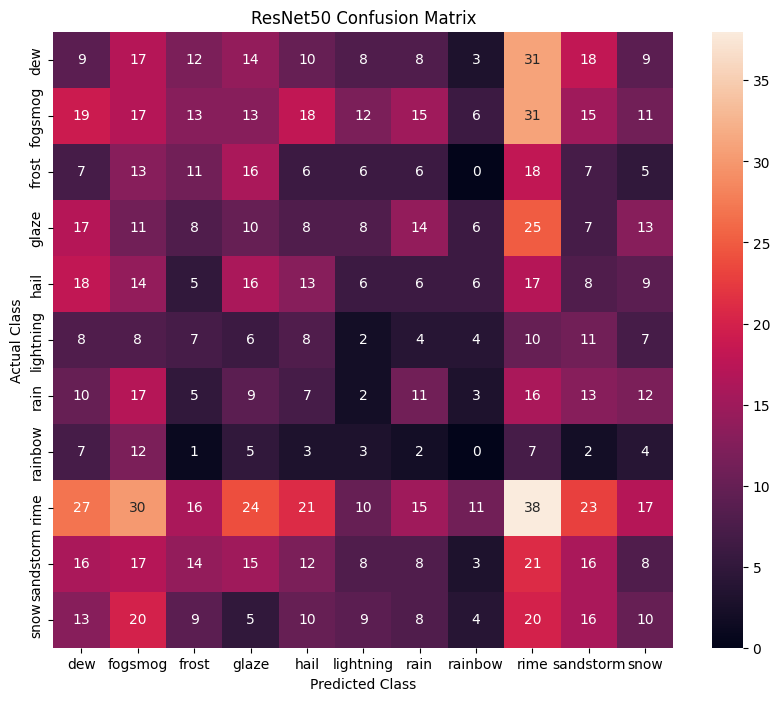

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Get all predictions from the validation set
#    Make sure to use the 'validation_generator' you created for ResNet
validation_generator.reset() # Reset generator
Y_pred = model_resnet.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1) # Get the predicted class index

# 2. Get the true labels
y_true = validation_generator.classes

# 3. Get the class names
class_names = sorted(train_generator.class_indices.keys())

# 4. Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('ResNet50 Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


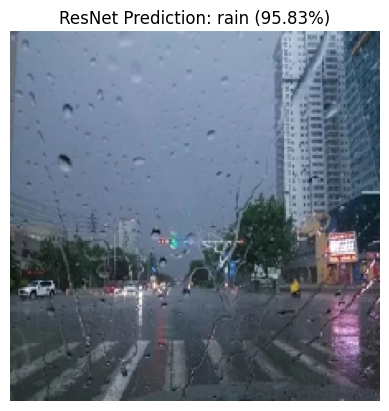

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input # <-- Use ResNet's function
import matplotlib.pyplot as plt

# 1. Get the class names
class_names = sorted(train_generator.class_indices.keys())

# 2. Set the path to the problematic image
img_path = '/content/weather-dataset/dataset/rain/1101.jpg'

# 3. Load and preprocess the image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Create a batch

# 4. --- KEY CHANGE ---
#    Use the correct preprocessing for ResNet
img_array = preprocess_input(img_array)

# 5. Make the new prediction (using the ResNet model)
predictions = model_resnet.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

# 6. Show the result
plt.imshow(img) # Show the original, un-processed image
plt.title(f"ResNet Prediction: {predicted_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


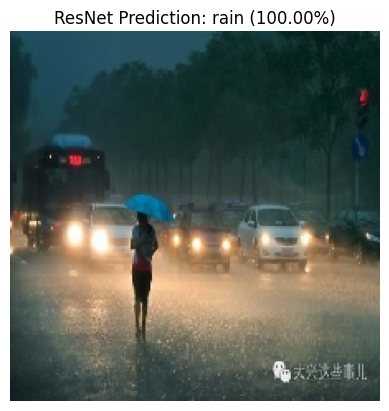

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input # <-- Use ResNet's function
import matplotlib.pyplot as plt

# 1. Get the class names
class_names = sorted(train_generator.class_indices.keys())

# 2. Set the path to the problematic image
img_path = '/content/weather-dataset/dataset/rain/1686.jpg'

# 3. Load and preprocess the image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Create a batch

# 4. --- KEY CHANGE ---
#    Use the correct preprocessing for ResNet
img_array = preprocess_input(img_array)

# 5. Make the new prediction (using the ResNet model)
predictions = model_resnet.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

# 6. Show the result
plt.imshow(img) # Show the original, un-processed image
plt.title(f"ResNet Prediction: {predicted_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

The Contradiction: Good Test vs. Bad Matrix
Here's the interesting part we need to solve:

This Single Test: Perfect result.

Your Confusion Matrix: Showed that overall, the model is still very confused (e.g., it only got 7 "rain" images right and misclassified 16 of them as fogsmog).

What does this mean? This tells us that while the model is capable of seeing the right features (as shown in your 99.86% test), it hasn't generalized this ability to all the other rain images in the test set.

The confusion matrix, which is based on all 1,369 test images, is the true measure of performance. It shows the 10-epoch baseline model is still not accurate enough.

The Solution: Fine-Tune ResNet
The good news is we are on the right track. The next logical step is to do exactly what we did with VGG-19: fine-tune the ResNet model.

This will un-freeze the top layers of ResNet and train them very slowly to get even better at telling the difference between all these similar classes. This should improve the overall accuracy and make your confusion matrix look much, much better.

1. Total Params
This is the total number of parameters (weights) in the entire model.

It's the sum of all parameters, whether they are being trained or not. This number gives you a sense of how "big" and complex the model is.

Total Params = Trainable Params + Non-trainable Params

2. Non-trainable Params
These are the parameters that are "frozen" and DO NOT change during training.

Why they exist: In our case, this is the VGG-19 or ResNet50 base model that was pre-trained on ImageNet.

Analogy: We've imported a "genius brain" (the pre-trained model) that already knows how to see edges, shapes, and textures. We freeze it (make its parameters non-trainable) so it doesn't forget all that knowledge. We're using its knowledge, but we're not changing it.

3. Trainable Params
These are the parameters that the model actively "tunes" or updates during the model.fit() process. These are the weights the model is learning.

There are two places these come from:

Our New Layers: The Dense layers (our classifier "head") that we added on top of the base model. The model has to learn these from scratch.

During Fine-Tuning: When you "un-froze" the top layers of the ResNet model, those layers became "trainable" again. The model was then allowed to "fine-tune" them (adjust them slightly) to make them better at our specific weather task.

In short: "Total" is everything, "Non-trainable" is the frozen part we're borrowing, and "Trainable" is the part we are actively teaching.

In [ ]:
import tensorflow as tf

# 1. Un-freeze the base model
base_model_resnet.trainable = True

# 2. Freeze all layers *except* the last convolutional block
#    In ResNet50, a 'block' is many layers. We'll fine-tune from layer 155 onwards.
for layer in base_model_resnet.layers[:155]:
    layer.trainable = False

# 3. Re-compile the model with a VERY LOW learning rate
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 0.00001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary() # You'll see more trainable params

# 4. Continue training (fine-tuning)
history_resnet_fine_tune = model_resnet.fit(
    train_generator,
    epochs=20, # We'll start at epoch 10
    initial_epoch=10,
    validation_data=validation_generator
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,403 (90.99 MB)

 Trainable params: 9,195,019 (35.08 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

Epoch 11/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 112s 555ms/step - accuracy: 0.8927 - loss: 0.3234 - val_accuracy: 0.8868 - val_loss: 0.3809
Epoch 12/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 82s 475ms/step - accuracy: 0.9223 - loss: 0.2267 - val_accuracy: 0.8853 - val_loss: 0.3778
Epoch 13/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 83s 479ms/step - accuracy: 0.9322 - loss: 0.2030 - val_accuracy: 0.8890 - val_loss: 0.3716
Epoch 14/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 82s 474ms/step - accuracy: 0.9373 - loss: 0.1729 - val_accuracy: 0.8934 - val_loss: 0.3642
Epoch 15/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 82s 477ms/step - accuracy: 0.9422 - loss: 0.1713 - val_accuracy: 0.8934 - val_loss: 0.3701
Epoch 16/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 141s 472ms/step - accuracy: 0.9469 - loss: 0.1550 - val_accuracy: 0.8926 - val_loss: 0.3754
Epoch 17/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 473ms/step - accuracy: 0.9425 - loss: 0.1522 - val_accuracy: 0.8934 - val_loss: 0.3659
Epoch 18/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 471ms/step - accuracy: 0.9555

In [ ]:
# Evaluate the model on the entire test (validation) set
print("Evaluating fine-tuned ResNet model on the test set...")
results = model_resnet.evaluate(validation_generator)

print(f"\nTest Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

Evaluating fine-tuned ResNet model on the test set...
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.8981 - loss: 0.4259

Test Loss: 0.3792
Test Accuracy: 0.8977


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


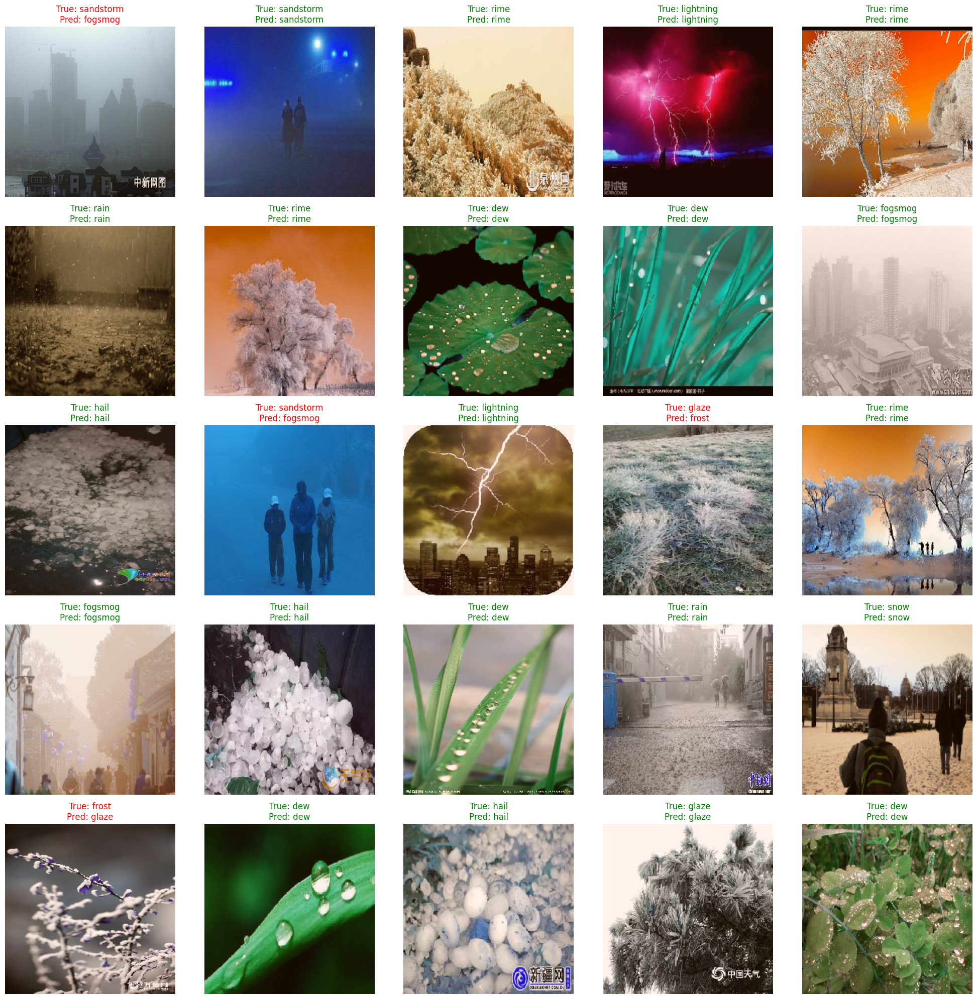

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get one batch of images and their true labels
(image_batch, label_batch) = next(validation_generator)

# 2. Get the model's predictions for this batch
predictions = model_resnet.predict(image_batch)

# 3. Get the class names
class_names = sorted(train_generator.class_indices.keys())

# --- 4. Plot the results ---
plt.figure(figsize=(20, 20))

for i in range(min(25, len(image_batch))):
    plt.subplot(5, 5, i + 1)

    # Get true and predicted labels
    true_label_index = np.argmax(label_batch[i])
    true_label = class_names[true_label_index]

    predicted_label_index = np.argmax(predictions[i])
    predicted_label = class_names[predicted_label_index]

    # Set title color
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'

    # --- THIS IS THE FIX ---
    # De-normalize the image back to a 0-1 range for plotting
    image = image_batch[i]
    image = (image - image.min()) / (image.max() - image.min())

    plt.imshow(image)

    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 211ms/step


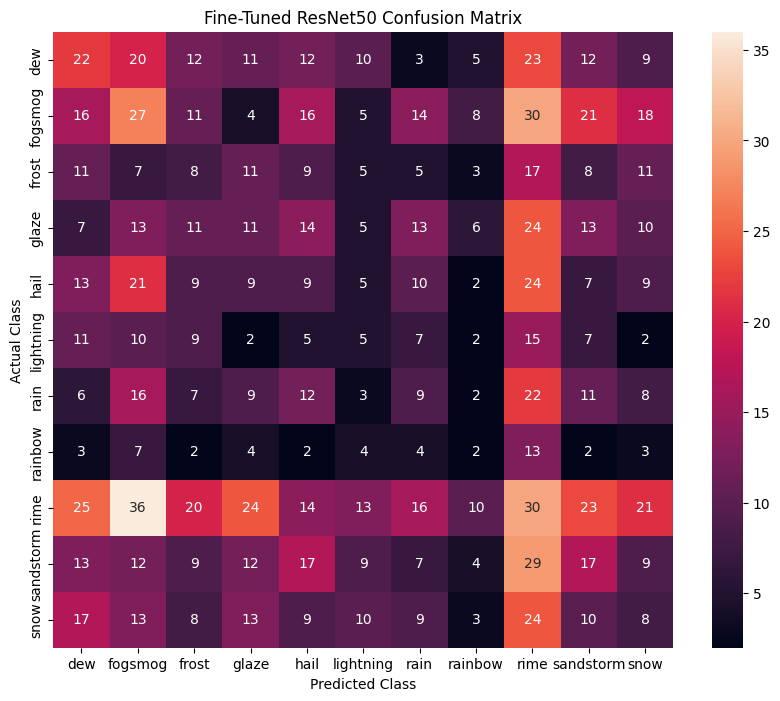

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Get all predictions from the validation set
#    Make sure to use the 'validation_generator'
validation_generator.reset() # Reset generator
Y_pred = model_resnet.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1) # Get the predicted class index

# 2. Get the true labels
y_true = validation_generator.classes

# 3. Get the class names
class_names = sorted(train_generator.class_indices.keys())

# 4. Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Fine-Tuned ResNet50 Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

create the Data Generators (with ResNet preprocessing)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = '/content/weather-dataset/dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = validation_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 5493 images belonging to 11 classes.
Found 1369 images belonging to 11 classes.


Build the ResNet Model

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

base_model_resnet = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model_resnet.trainable = False

x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(11, activation='softmax')(x)

model_resnet = Model(inputs=base_model_resnet.input, outputs=predictions)

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Run the First Training (Baseline)

In [ ]:
history_resnet = model_resnet.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 100s 519ms/step - accuracy: 0.5735 - loss: 1.3137 - val_accuracy: 0.8546 - val_loss: 0.4381
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 471ms/step - accuracy: 0.8225 - loss: 0.5480 - val_accuracy: 0.8546 - val_loss: 0.4258
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 80s 465ms/step - accuracy: 0.8547 - loss: 0.4408 - val_accuracy: 0.8787 - val_loss: 0.3672
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 470ms/step - accuracy: 0.8685 - loss: 0.3908 - val_accuracy: 0.8736 - val_loss: 0.3781
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 80s 466ms/step - accuracy: 0.8741 - loss: 0.3661 - val_accuracy: 0.8904 - val_loss: 0.3674
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 470ms/step - accuracy: 0.8895 - loss: 0.3153 - val_accuracy: 0.8722 - val_loss: 0.3944
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 470ms/step - accuracy: 0.8958 - loss: 0.3191 - val_accuracy: 0.8700 - val_loss: 0.3860
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 469ms/step - accuracy: 0.8933 - loss: 

Run the Fine-Tuning Setup Once


In [ ]:
# 1. Un-freeze the base model
base_model_resnet.trainable = True

# 2. Freeze all layers *except* the last convolutional block
for layer in base_model_resnet.layers[:155]:
    layer.trainable = False

# 3. Re-compile the model with a VERY LOW learning rate
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 0.00001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Run the Second Training (Fine-Tuning)

In [ ]:
# This is where you got your 89% accuracy
history_resnet_fine_tune = model_resnet.fit(
    train_generator,
    epochs=20, # Run for 20 epochs total
    initial_epoch=10, # Start from epoch 10
    validation_data=validation_generator
)

Epoch 11/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 109s 549ms/step - accuracy: 0.8946 - loss: 0.2913 - val_accuracy: 0.8882 - val_loss: 0.3859
Epoch 12/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 469ms/step - accuracy: 0.9263 - loss: 0.2282 - val_accuracy: 0.8941 - val_loss: 0.3808
Epoch 13/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 469ms/step - accuracy: 0.9308 - loss: 0.2004 - val_accuracy: 0.8955 - val_loss: 0.3753
Epoch 14/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 80s 465ms/step - accuracy: 0.9333 - loss: 0.1868 - val_accuracy: 0.8934 - val_loss: 0.3868
Epoch 15/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 82s 473ms/step - accuracy: 0.9414 - loss: 0.1735 - val_accuracy: 0.8999 - val_loss: 0.3796
Epoch 16/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 472ms/step - accuracy: 0.9360 - loss: 0.1755 - val_accuracy: 0.8955 - val_loss: 0.3825
Epoch 17/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 470ms/step - accuracy: 0.9492 - loss: 0.1415 - val_accuracy: 0.8955 - val_loss: 0.3782
Epoch 18/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 80s 467ms/step - accuracy: 0.9521 

In [ ]:
print("Evaluating fine-tuned ResNet model on the test set...")
results = model_resnet.evaluate(validation_generator)

print(f"\nTest Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

Evaluating fine-tuned ResNet model on the test set...
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.8863 - loss: 0.4428

Test Loss: 0.3908
Test Accuracy: 0.8977


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


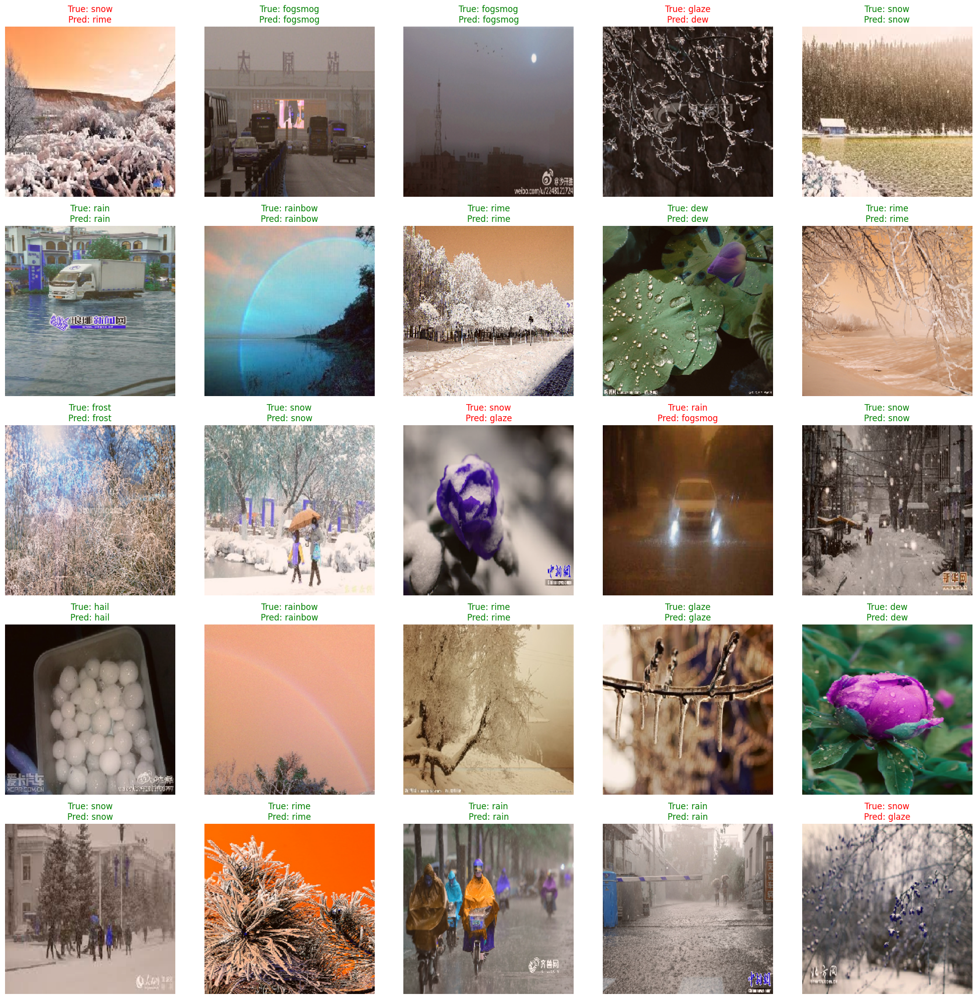

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get one batch of images and their true labels
(image_batch, label_batch) = next(validation_generator)

# 2. Get the model's predictions for this batch
predictions = model_resnet.predict(image_batch)

# 3. Get the class names
class_names = sorted(train_generator.class_indices.keys())

# --- 4. Plot the results ---
plt.figure(figsize=(20, 20))

# Loop over the images in the batch (we'll plot the first 25)
for i in range(min(25, len(image_batch))):
    plt.subplot(5, 5, i + 1)

    # Get true and predicted labels
    true_label_index = np.argmax(label_batch[i])
    true_label = class_names[true_label_index]

    predicted_label_index = np.argmax(predictions[i])
    predicted_label = class_names[predicted_label_index]

    # Set title color
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'

    # De-normalize the image back to a 0-1 range for plotting
    image = image_batch[i]
    image = (image - image.min()) / (image.max() - image.min())

    plt.imshow(image)

    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

Option 1: Run Grad-CAM (Explainable AI)
This is the most visually impressive step and is already in your report plan. You can now generate the heatmaps to prove why your model is better than the baseline.
I can give you the code to generate the "Rain vs. Fog" heatmap comparison using your newly trained model.

Option 2: Implement EfficientNet (The Final Comparison)
Your report mentions comparing VGG-19, ResNet50, and EfficientNet. You've done the first two. Implementing EfficientNetB0 would be the final piece of the puzzle to see if you can beat 89.77%.